<a href="https://colab.research.google.com/github/IrisCheon/NLP-practice/blob/main/Liberals_vs_Conservatives_on_Reddit_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Comparing Liberal and Conservative Discussions on Reddit

This project explores differences between Liberal and Conservative Reddit posts using exploratory data analysis (EDA) and TF-IDF. The analysis focuses on posting patterns, text length distributions, and characteristic keywords associated with each political group.



In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("neelgajare/liberals-vs-conservatives-on-reddit-13000-posts")

print("Path to dataset files:", path)

100%|██████████| 2.09M/2.09M [00:00<00:00, 41.6MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/neelgajare/liberals-vs-conservatives-on-reddit-13000-posts/versions/4


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

In [3]:
os.listdir(path)

['file_name.csv']

#■ 데이터 확인

In [5]:
df = pd.read_csv(os.path.join(path, "file_name.csv"))
df.head()

,Title,Political Lean,Score,Id,Subreddit,URL,Num of Comments,Text,Date Created
0,"No matter who someone is, how they look like, ...",Liberal,1,t5fybt,socialism,https://v.redd.it/ng5fyl7hp2l81,0,NaN,1.646272e+09
1,Biden speech draws 38.2 million U.S. TV viewers,Liberal,6,t5fqdn,democrats,https://www.reuters.com/world/us/biden-speech-...,1,NaN,1.646271e+09
2,State of the union,Liberal,1,t5fj9a,DemocraticSocialism,https://www.reddit.com/r/DemocraticSocialism/c...,1,Who watched the state of the union last night ...,1.646270e+09
3,We Should Just Give Poor People Money,Liberal,7,t5f7n9,SocialDemocracy,https://youtu.be/a80kRjpubG0,3,NaN,1.646270e+09
4,Do it for the Dew,Liberal,6,t5es2c,democrats,https://i.redd.it/drmunn90f2l81.jpg,1,NaN,1.646268e+09


In [11]:
df.info()

#Text는 NaN값이 많아서 보기 어려울 것 같음

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12854 entries, 0 to 12853
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Title            12854 non-null  object 
 1   Political Lean   12854 non-null  object 
 2   Score            12854 non-null  int64  
 3   Id               12854 non-null  object 
 4   Subreddit        12854 non-null  object 
 5   URL              12854 non-null  object 
 6   Num of Comments  12854 non-null  int64  
 7   Text             2428 non-null   object 
 8   Date Created     12854 non-null  float64
dtypes: float64(1), int64(2), object(6)
memory usage: 903.9+ KB


In [10]:
df.shape

(12854, 9)

In [7]:
df.columns

Index(['Title', 'Political Lean', 'Score', 'Id', 'Subreddit', 'URL',
       'Num of Comments', 'Text', 'Date Created'],
      dtype='object')

In [12]:
df["Political Lean"].value_counts()

,count
Political Lean,
Liberal,8319
Conservative,4535


In [15]:
pd.crosstab(df["Political Lean"], df["Text"].isnull())

# Conservative에서 Text가 NaN인 비율이 더 높음(1/3.5)
# Liberal 은 1/4.5 정도?

Text,False,True
Political Lean,,
Conservative,957,3578
Liberal,1471,6848


## ■ Score 분석

In [34]:
df["Score"].describe()

,Score
count,12854.000000
mean,118.558270
std,498.888034
min,0.000000
25%,3.000000
50%,12.000000
75%,65.000000
max,25055.000000


In [19]:
df["Score"].value_counts()

,count
Score,
0,1145
2,825
3,736
1,648
4,565
...,...
468,1
655,1
523,1


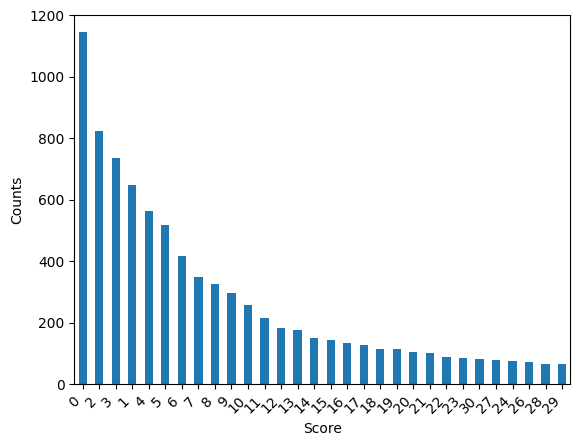

In [56]:
df["Score"].value_counts().head(30).plot(kind="bar")
plt.xticks(rotation = 45, ha = "right")
plt.ylabel("Counts")
plt.show()

※ Score는 0점부터 거의 오름차순으로 수가 많음
- 최고 점수는 25055 점이지만, 75%까지가 65점이므로 대부분 점수가 낮음 확인 가능

In [61]:
df.groupby("Political Lean")["Score"].describe()

,count,mean,std,min,25%,50%,75%,max
Political Lean,,,,,,,,
Conservative,4535.0,39.776847,396.990388,0.0,1.0,5.0,15.0,25055.0
Liberal,8319.0,161.504989,541.710457,0.0,6.0,24.0,112.0,14878.0


※ Conservative의 평균 점수가 현저히 낮지만, max는 Conservative가 훨씬 높음
- 전반적으로 Liberal 성향인지 의문

In [66]:
liberal_top = df[df["Political Lean"] == "Liberal"].sort_values("Score", ascending = False)

pd.set_option("display.max_colwidth", 150)
liberal_top[["whole_texts", "Score"]].head(10)

,whole_texts,Score
3187,I want this too,14878
1335,Remember who the enemy is:,12712
1043,"Frito-Lay worker Brandon Ingram was severely electrocuted on the job, disabled and denied medical care. Now Brandon, his wife, and children are be...",12577
765,Lanlords are leeches,10281
359,Meanwhile let's not look at these,9592
172,Israeli police beats a 12 year old girl in East Jerusalem,9170
3282,Andrew Yang states the truth the Neoliberals don’t want to hear,7239
3240,Bernie Sanders says Democrats are failing: ‘The party has turned its back on the working class’,7222
1766,We're f**ked aren't we.,6996
2013,Fuck Joe Biden,6603


In [67]:
conservative_top = df[df["Political Lean"] == "Conservative"].sort_values("Score", ascending = False)

conservative_top[["whole_texts", "Score"]].head(10)

,whole_texts,Score
9717,"Fuck Vladimir Putin. Long Live Ukraine. That is all.\n\nEdit: Russian sympathizers, go fuck yourselves",25055
10937,"Hackers Just Leaked the Names of 92,000 ‘Freedom Convoy’ Donors",3847
10414,Rand Paul Introduces Bill To Abolish “Nonjudicial” Civil Forfeiture,2511
9504,Ukrainian Govt. handing out guns to anyone who wishes to fight,1976
8815,The outrage over the Russian invasion of Ukraine should be the same for every war/invasion. That’s it.,1874
8939,"'I was robbed by people with badges' | Marine veteran says police stole his life savings, fighting to end legal police tactic",1770
10562,Rep. Ilhan Omar to introduce legislation proposing new restrictions on no-knock warrants,1688
10810,Dear Canadians. Your government has decided that it can unilaterally seize your bank accounts. Please go to your bank and withdraw as much cash as...,1565
10984,"FYI, a tax refund is not free money from the government. It a partial return on the interest free loan you approved to provide...",1518
11066,"The left wing media is covering the Trucker Rallies the way the right wing media covered the BLM rallies. With extreme prejudice, straw man argume...",1513


- Liberal은 상위 text 대부분 길이가 짧으며 주제가 다양함
- Conservative는 최고 Score 1개 외 전반적으로 Score가 낮으며,
    - 주제는 Ukraine/Russia 관련이 자주 언급됨

## ■ Text Length 분석

In [36]:
df["Text"] = df["Text"].fillna("")
df.head()

,Title,Political Lean,Score,Id,Subreddit,URL,Num of Comments,Text,Date Created
0,"No matter who someone is, how they look like, ...",Liberal,1,t5fybt,socialism,https://v.redd.it/ng5fyl7hp2l81,0,,1.646272e+09
1,Biden speech draws 38.2 million U.S. TV viewers,Liberal,6,t5fqdn,democrats,https://www.reuters.com/world/us/biden-speech-...,1,,1.646271e+09
2,State of the union,Liberal,1,t5fj9a,DemocraticSocialism,https://www.reddit.com/r/DemocraticSocialism/c...,1,Who watched the state of the union last night ...,1.646270e+09
3,We Should Just Give Poor People Money,Liberal,7,t5f7n9,SocialDemocracy,https://youtu.be/a80kRjpubG0,3,,1.646270e+09
4,Do it for the Dew,Liberal,6,t5es2c,democrats,https://i.redd.it/drmunn90f2l81.jpg,1,,1.646268e+09


In [39]:
df["whole_texts"] = df["Title"] + " " + df["Text"]
df.head()

,Title,Political Lean,Score,Id,Subreddit,URL,Num of Comments,Text,Date Created,label,whole_texts
0,"No matter who someone is, how they look like, ...",Liberal,1,t5fybt,socialism,https://v.redd.it/ng5fyl7hp2l81,0,,1.646272e+09,0,"No matter who someone is, how they look like, ..."
1,Biden speech draws 38.2 million U.S. TV viewers,Liberal,6,t5fqdn,democrats,https://www.reuters.com/world/us/biden-speech-...,1,,1.646271e+09,0,Biden speech draws 38.2 million U.S. TV viewers
2,State of the union,Liberal,1,t5fj9a,DemocraticSocialism,https://www.reddit.com/r/DemocraticSocialism/c...,1,Who watched the state of the union last night ...,1.646270e+09,0,State of the union Who watched the state of th...
3,We Should Just Give Poor People Money,Liberal,7,t5f7n9,SocialDemocracy,https://youtu.be/a80kRjpubG0,3,,1.646270e+09,0,We Should Just Give Poor People Money
4,Do it for the Dew,Liberal,6,t5es2c,democrats,https://i.redd.it/drmunn90f2l81.jpg,1,,1.646268e+09,0,Do it for the Dew


In [41]:
df["text_lengths"] = df["whole_texts"].str.len()
df.groupby("Political Lean")["text_lengths"].describe()

,count,mean,std,min,25%,50%,75%,max
Political Lean,,,,,,,,
Conservative,4535.0,262.169129,913.872304,2.0,56.0,80.0,143.0,30409.0
Liberal,8319.0,313.924150,1272.542758,2.0,58.0,80.0,142.5,31578.0


※ 글자수 평균은 Liberal이 더 높지만, 75%까지는 거의 동일한 수치. 상위 25%에서 차이가 나는 듯

In [90]:
df.groupby("Political Lean")["text_lengths"].quantile(
    [0.5, 0.75, 0.9, 0.95, 0.99]
)

Political Lean      
Conservative    0.50      80.00
                0.75     143.00
                0.90     501.00
                0.95    1019.30
                0.99    3160.04
Liberal         0.50      80.00
                0.75     142.50
                0.90     446.20
                0.95    1070.10
                0.99    4694.42
Name: text_lengths, dtype: float64

- 90%까지는 얼추 비슷하지만(90% 시점ㅇ느 conservative가 높음)
    - 95% 시점에서 Liberal이 더 길며
    - 99% 는 대폭 차이남(Conservative 3160, Liberal 4694)

#■ TF-IDF

In [37]:
df["label"] = df["Political Lean"].map({
    "Liberal": 0,
    "Conservative": 1
})

In [38]:
df["label"].value_counts()

,count
label,
0,8319
1,4535


In [68]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [69]:
liberal_texts = df[df["label"]==0]["whole_texts"]
conservative_texts = df[df["label"]==1]["whole_texts"]

In [77]:
vectorizer_lib = TfidfVectorizer(
    stop_words="english",
    ngram_range = (1, 2),
    max_features = 10000,
    min_df=10
)
X_lib = vectorizer_lib.fit_transform(liberal_texts)

vectorizer_con = TfidfVectorizer(
    stop_words="english",
    ngram_range = (1, 2),
    max_features = 10000,
    min_df=10
)
X_con = vectorizer_con.fit_transform(conservative_texts)

In [81]:
mean_scores_lib = np.asarray(X_lib.mean(axis=0)).flatten()
features_lib = vectorizer_lib.get_feature_names_out()

tfidf_df_lib = pd.DataFrame({
    "word" : features_lib,
    "score" : mean_scores_lib
})

tfidf_df_lib.sort_values("score", ascending=False).head(20)

,word,score
3474,trump,0.016251
2472,people,0.012616
404,biden,0.012409
2293,new,0.010285
3693,women,0.010266
1991,like,0.009422
1850,just,0.009017
3705,workers,0.008903
928,democrats,0.008434
3117,social,0.008355


In [91]:
mean_scores_con = np.asarray(X_con.mean(axis=0)).flatten()
features_con = vectorizer_con.get_feature_names_out()

tfidf_df_con = pd.DataFrame({
    "word" : features_con,
    "score" : mean_scores_con
})

tfidf_df_con.sort_values("score", ascending=False).head(20)

,word,score
1764,trump,0.027354
192,biden,0.023931
1787,ukraine,0.020964
255,capitalism,0.017708
1236,people,0.016126
1499,russia,0.015827
1374,putin,0.013305
743,government,0.011176
918,just,0.010879
997,like,0.010109


In [84]:
lib_words = set(tfidf_df_lib.sort_values("score", ascending=False).head(20)["word"])
con_words = set(tfidf_df_con.sort_values("score", ascending=False).head(20)["word"])

In [86]:
common_words = lib_words.intersection(con_words)
common_words

{'biden',
 'capitalism',
 'just',
 'like',
 'new',
 'people',
 'says',
 'state',
 'think',
 'trump',
 'war'}

In [87]:
lib_only = lib_words - con_words
lib_only

{'america',
 'democracy',
 'democrats',
 'party',
 'right',
 'social',
 'socialism',
 'women',
 'workers'}

In [88]:
con_only = con_words - lib_words
con_only

{'desantis',
 'don',
 'free',
 'government',
 'poll',
 'putin',
 'russia',
 'russian',
 'ukraine'}

- lib_only : {'america', 'democracy',  'democrats', 'party', 'right', 'social', 'socialism', 'women', 'workers'}
- con_only : {'desantis', 'don', 'free', 'government', 'poll', 'putin', 'russia', 'russian', 'ukraine'}

- 단순 상위20개 차집합임에도 집단의 특징이 직관적으로 보이는 편
    - lib은 democracy, social, women, workers
    - con은 free, government, poll, 그리고 russia-ukraine 관련

## ■ 중심 단어 text 분석

In [101]:
# Lib 진영의 democracy, workers, women 필터링

df[
    (df["Political Lean"]=="Liberal")
    &
    (df["whole_texts"].str.contains("democracy|workers|women"))
][["Score", "whole_texts", "text_lengths"]]

,Score,whole_texts,text_lengths
42,9,Between Gilead and OnlyFans: Notes on the Oppression of Women in 21st-Century Capitalism-Imperialism [https://kites-journal.org/2022/03/01/between...,379
71,35,"How extensive do you think state ownership should be? Social democrats in Western Europe and the Nordic countries (Germany, Sweden, Finland, Austr...",1665
187,3,"Immediate Peace Platforms: Minsk II, Cosmonaut Letters, DSA, and Personal Proposal Having compared four platforms put forward by so far - [Minsk I...",3114
188,2,"Immediate Peace Platforms: Minsk II, Cosmonaut Letters, DSA, and Personal Proposal Having compared four platforms put forward by so far - [Minsk I...",3017
227,456,"UPS slashed pay for part-time workers by up to $6 per hour, prompting a rapid response from UPS workers nationwide. On February 23, over 500 Teams...",258
...,...,...,...
8007,2,Verizon Labor Union Strike Beats Back Company Attack - Organize All Wireless Workers! Workers Vanguard No. 1092 1 July 2016\n\nVerizon workers alo...,11663
8009,2,EU: enemy of workers and immigrants - Brexit: defeat for the bankers and bosses of Europe! https://archive.is/xYApZ\n\nStatement of the Central Co...,7351
8012,1,"Killer Capitalist Sentenced to Country Club - 2010 West Virginia Mine Disaster On May 12, some six years after a fiery explosion at Upper Big Bran...",4700
8030,2,"Been dreaming up a new political system, curious if it was popular here? I don't have much experience with politics but have been constructing thi...",3312


In [102]:
# Con 진영의 government, free 필터링

df[
    (df["Political Lean"]=="Conservative")
    &
    (df["whole_texts"].str.contains("government|free"))
][["Score", "whole_texts", "text_lengths"]]

,Score,whole_texts,text_lengths
8344,0,"Liberty Lover's script for the funniest sketch show EVER!!! 1) After informing Derek about his sore stomach, George Floyd then tells him about how...",7736
8401,575,Part of Libertarianism is understanding and accepting that not everyone is you. This should not be difficult to understand: not everyone is a gun-...,538
8423,427,"The draft is slavery. I didn't think I needed to say this on a libertarian sub, but apparently I do Support Ukrainians and their right to protect ...",192
8427,0,"Russia and Ukraine: Summary History on how we got here – note this is informational and meant to inform the MOTIVATIONS of Russia, this a NOT A DE...",13521
8431,0,"Wah, the corporations being greedy are the cause of inflation!!1!1!1! Not the government who’s in charge of printing money!1!1!1!",130
...,...,...,...
12803,4,"Works of fiction with working anarchist society I am looking for works of fiction (novels, movies, TV shows, computer games) that are set in a wor...",763
12805,2,"what was the closest we ever got to a free market, and when was that? dont mention the internet, because its happening right now. Im talking about...",283
12814,6,"Why I am not an anarcho-capitalist Example: I will trade my freedom for a bit of security, if it ensures that we can regulate the use, creation, d...",1042
12822,5,"[x-post from FifthWorldPics] If you think about it, isn't this what the government has done to them?",101


# Conclusion

The analysis identified some differences in posting behavior and topic emphasis between Liberal and Conservative Reddit communities. Conservative posts showed a slightly higher proportion of missing text content, while Liberal posts contained a small number of substantially longer posts, leading to a higher average text length.

TF-IDF analysis revealed several distinctive keywords for each group. Liberal posts were more associated with terms such as *democracy*, *women*, and *workers*, while Conservative posts more frequently featured terms such as *government*, *free*, and topics related to Russia and Ukraine.

Overall, the observed differences appeared to reflect variations in discussion topics rather than fundamentally different language styles.